<a href="https://colab.research.google.com/github/Hrishik31/16_BIT_UP_DOWN_COUNTER/blob/main/time_series_modeling_and_forecasting_of_noaa_geomagnetic_activity_1994_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GeoMagNet: Hybrid Time-Series Forecasting of NOAA Geomagnetic Activity
Combined 11,630 daily records (1994–2025)


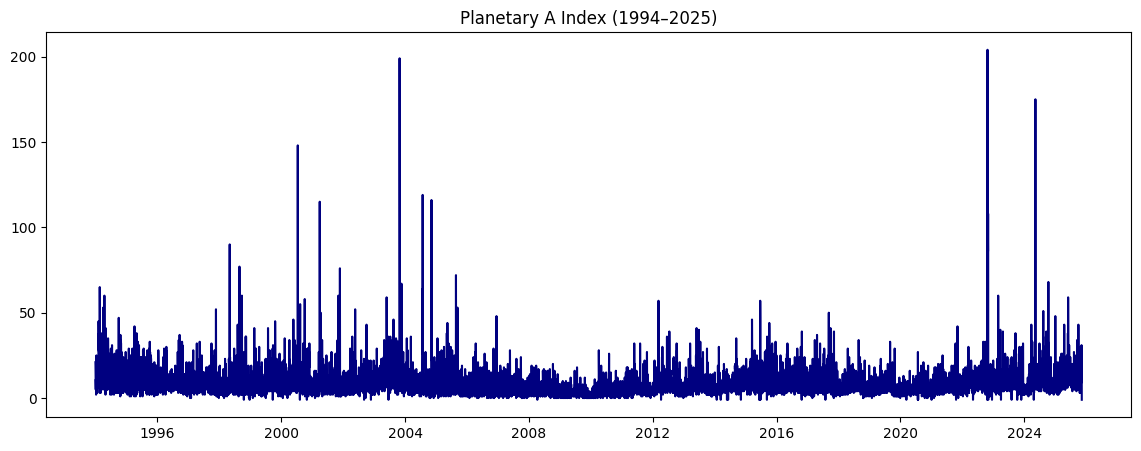

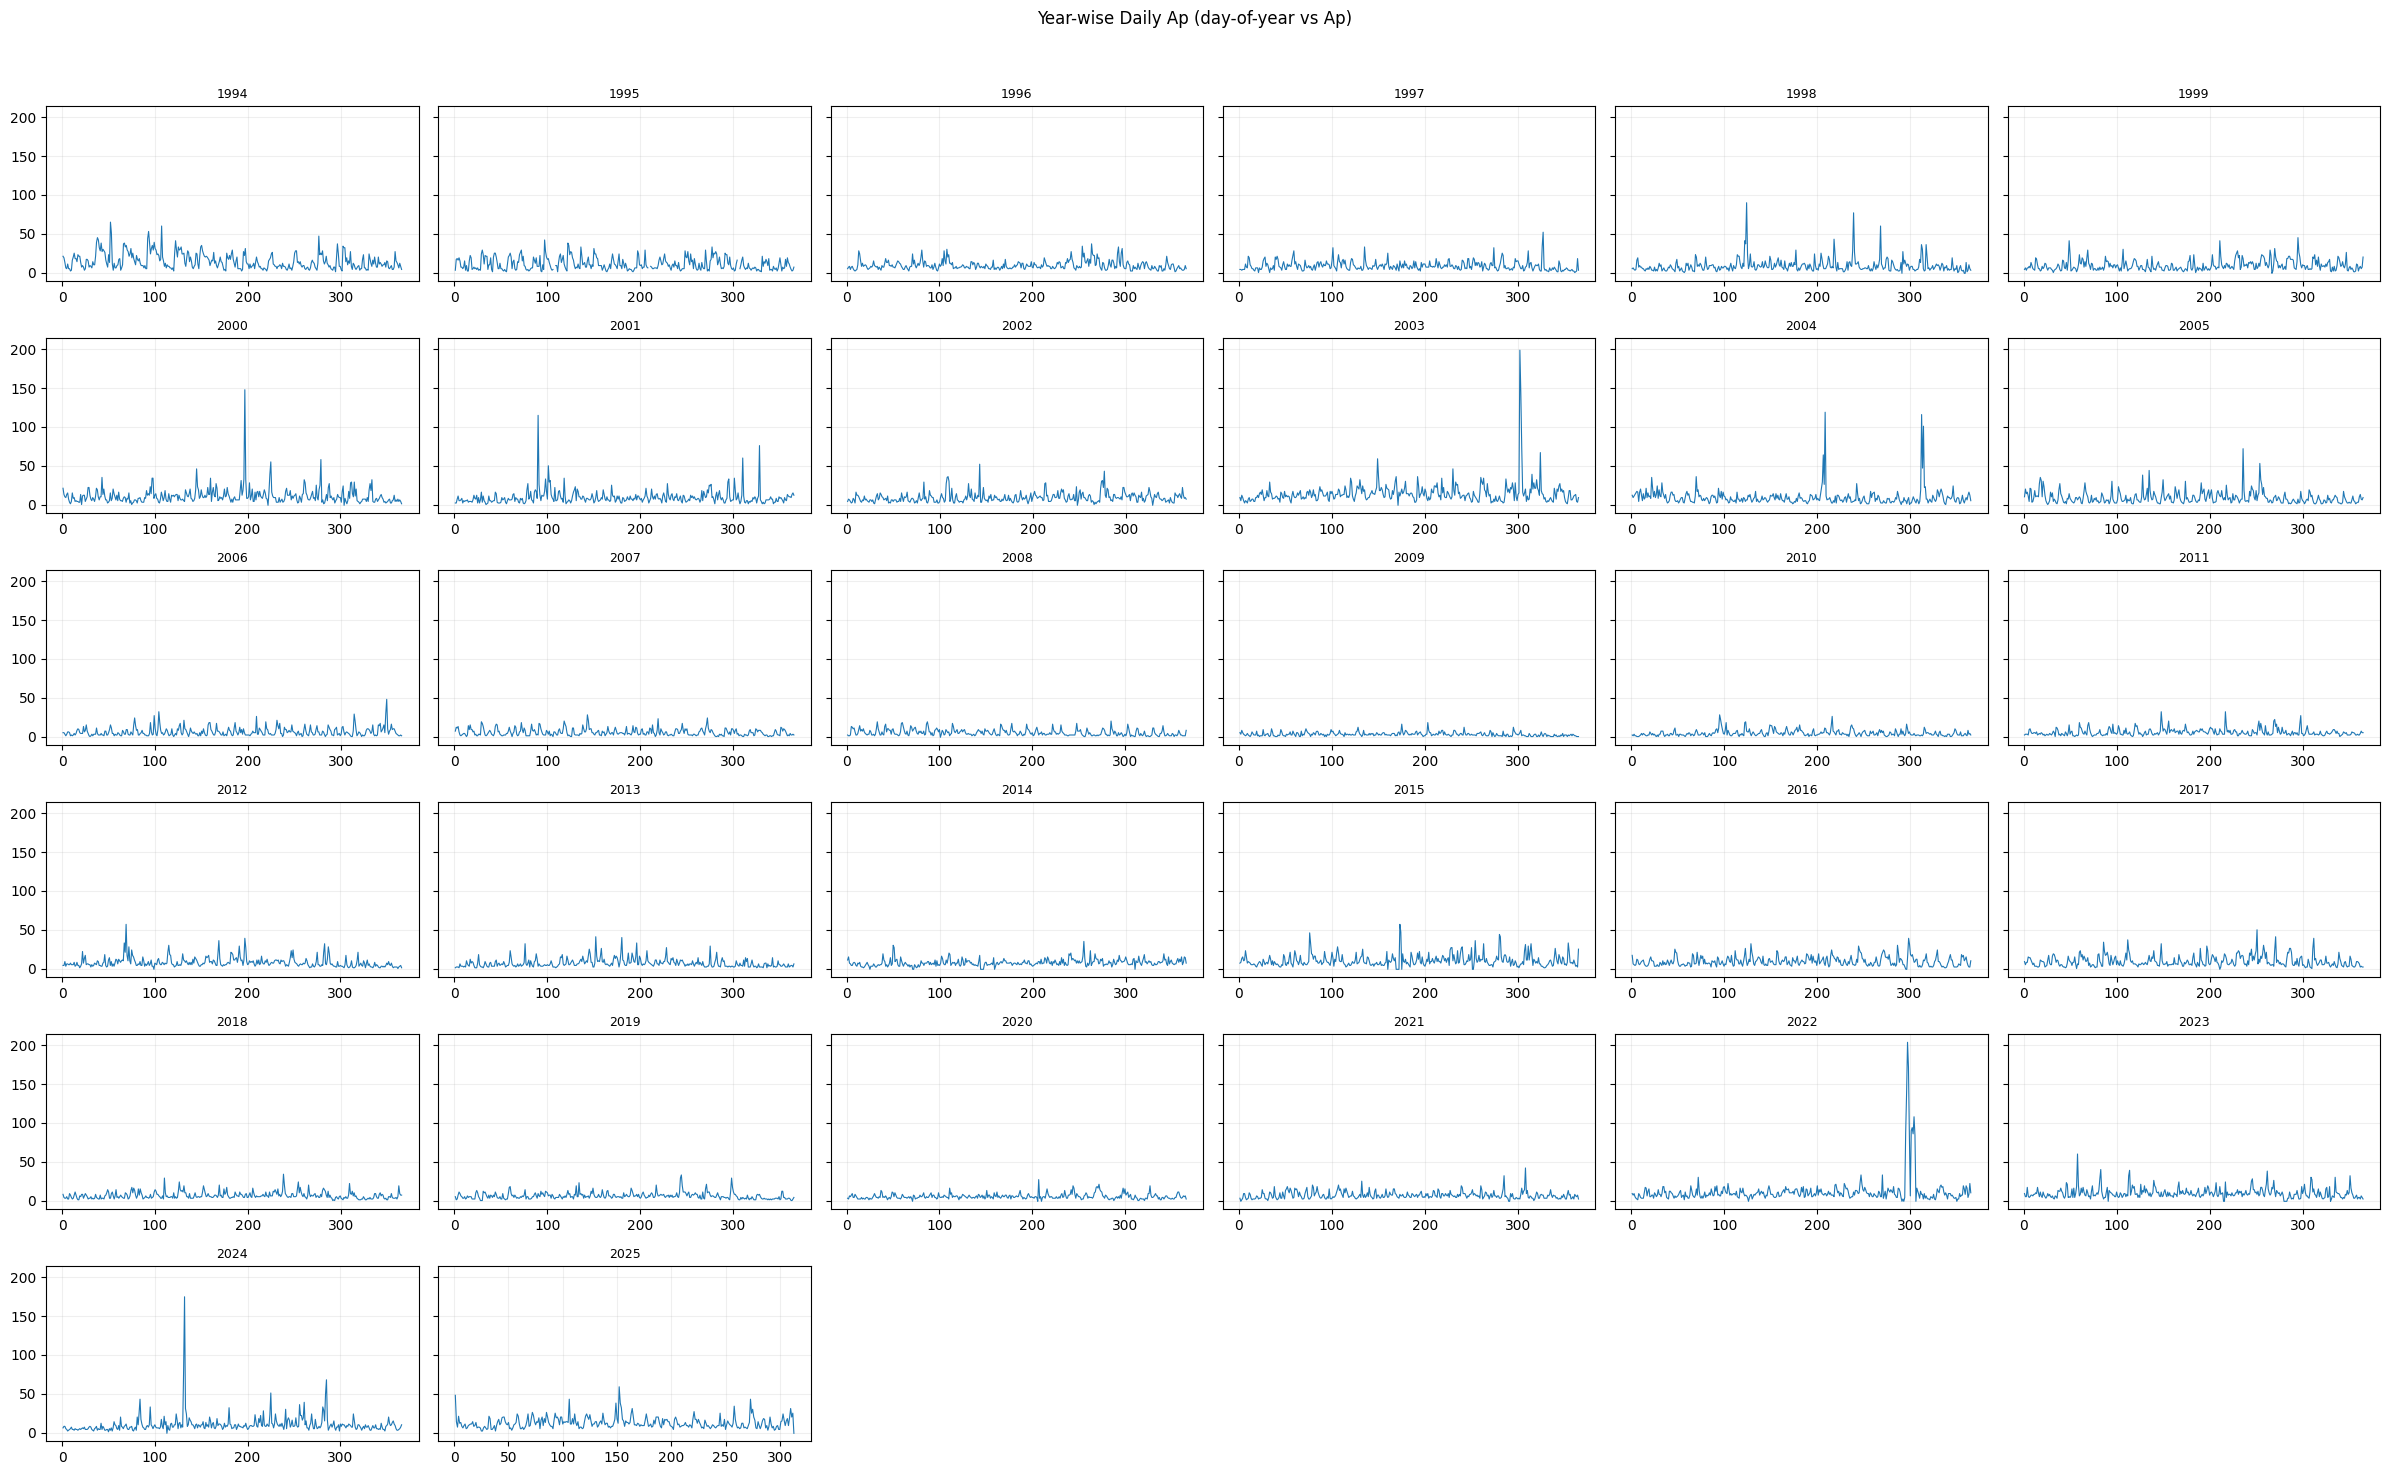

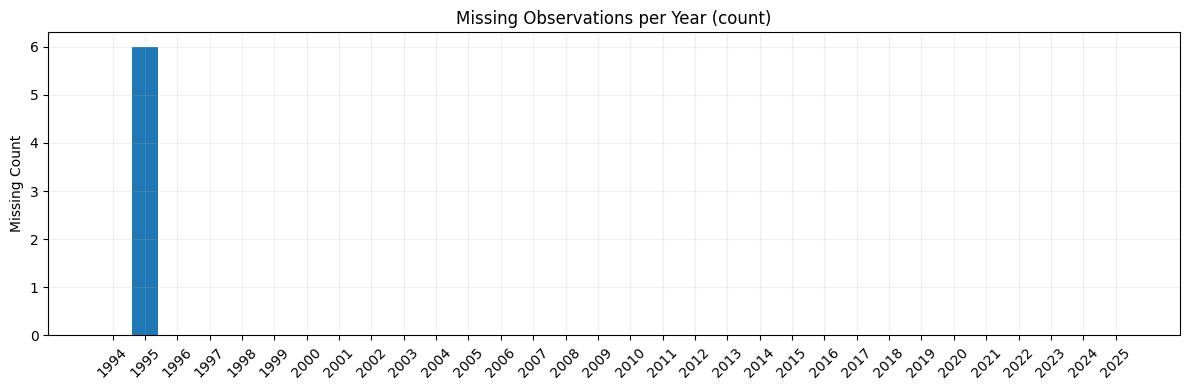

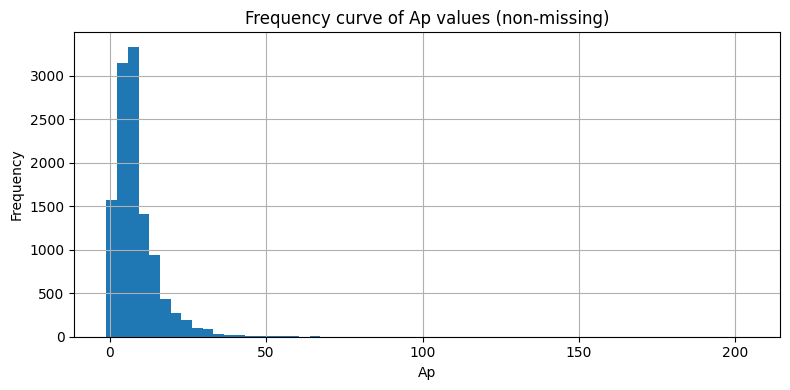

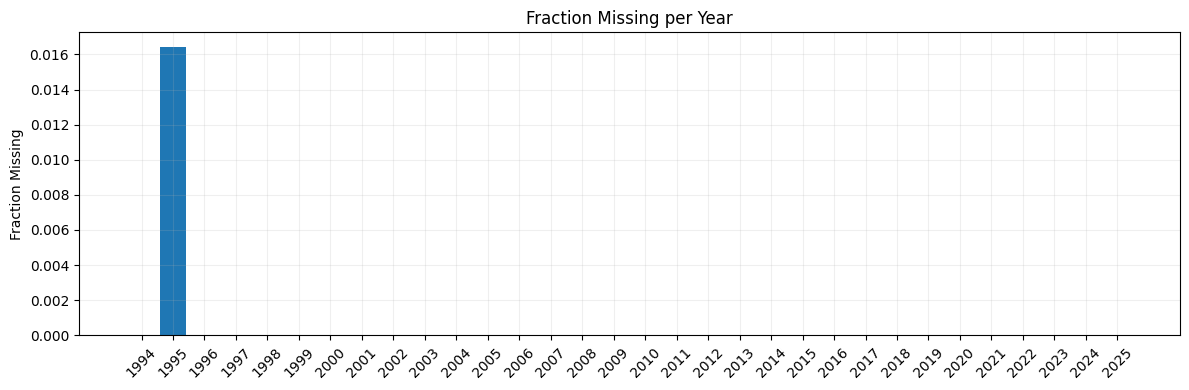

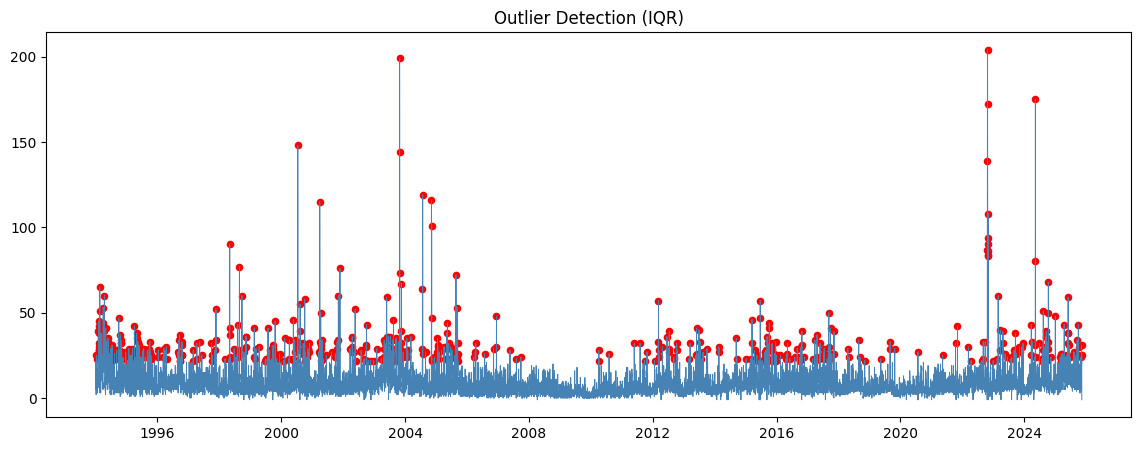

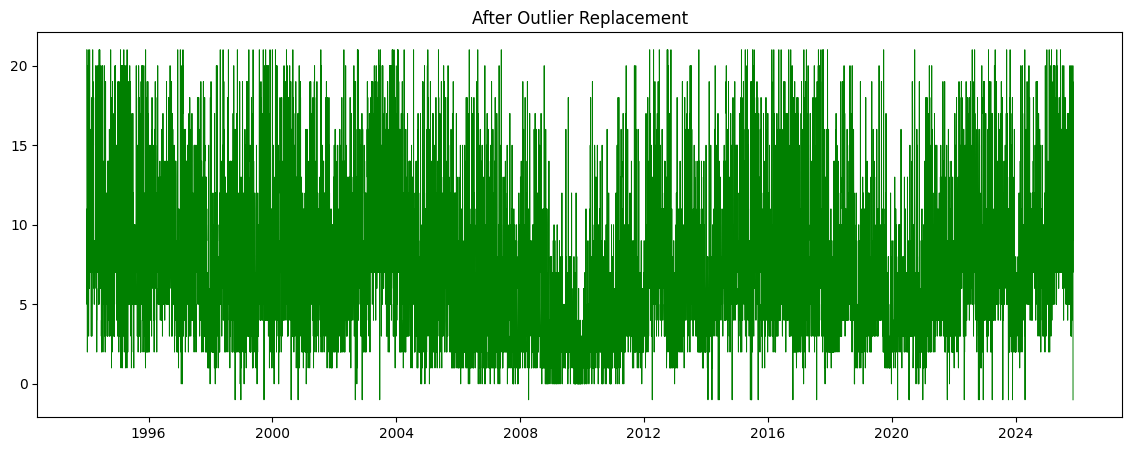

576 outliers replaced


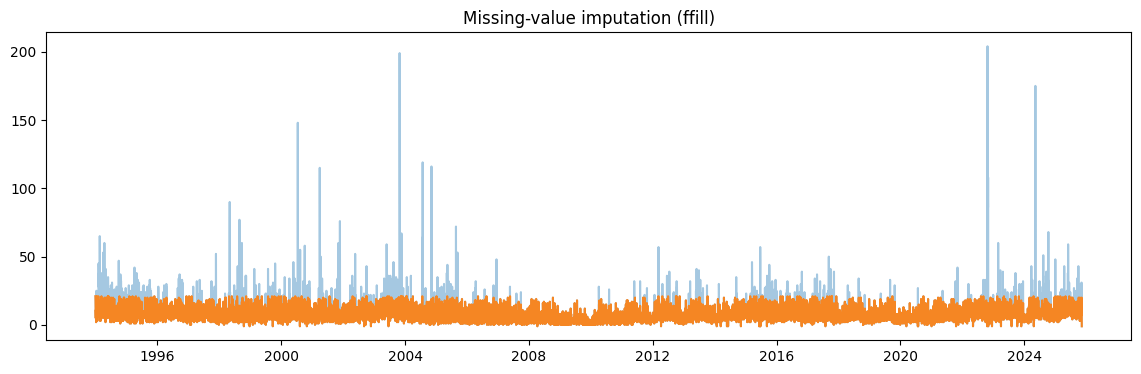

Trend detected: True, Seasonality detected: True


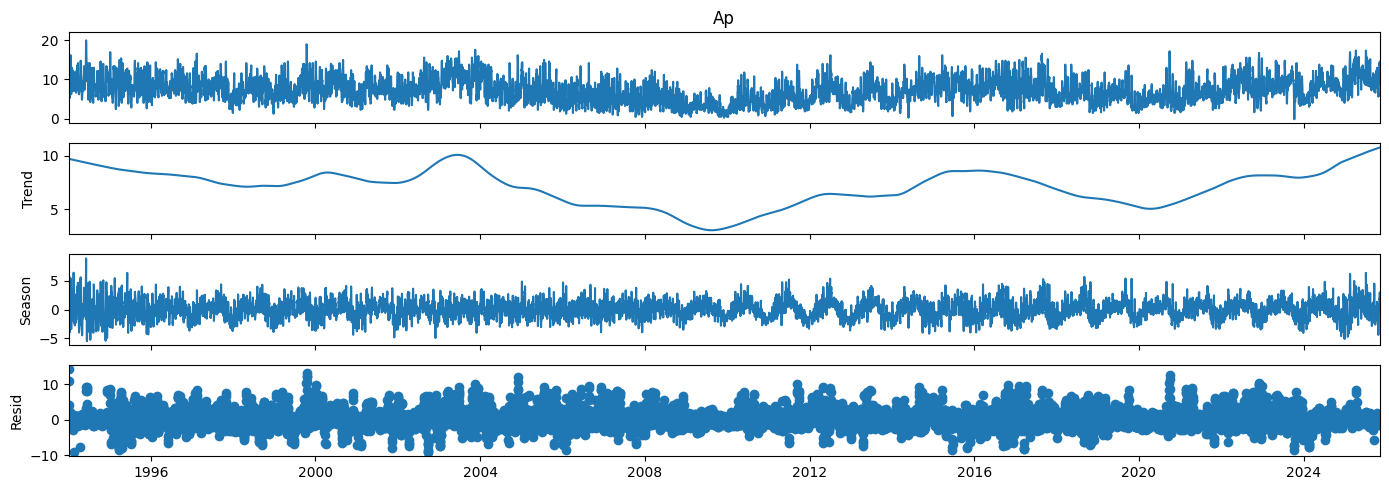

Applying ARIMA and SARIMAX models...


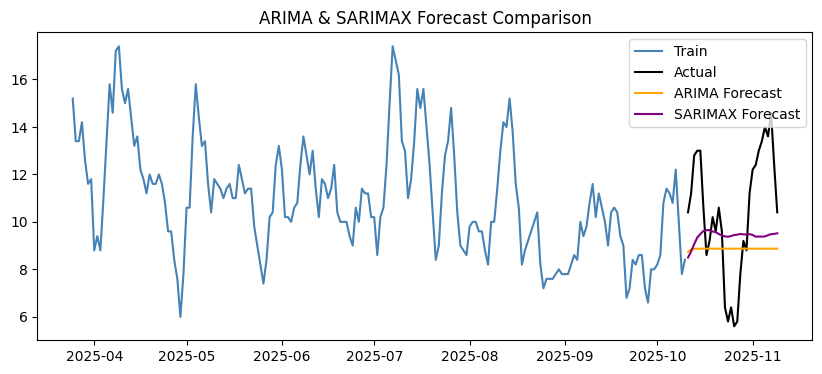

Training XGBoost
Training Conv1D-LSTM

MODEL PERFORMANCE COMPARISON
         Model       MSE      RMSE       MAE        R2
2      XGBoost  0.865790  0.930478  0.718296  0.906109
3  Conv1D_LSTM  0.993540  0.996765  0.770215  0.892255
1      SARIMAX  7.949012  2.819399  2.406286 -0.177058
0        ARIMA  9.093422  3.015530  2.579469 -0.346518


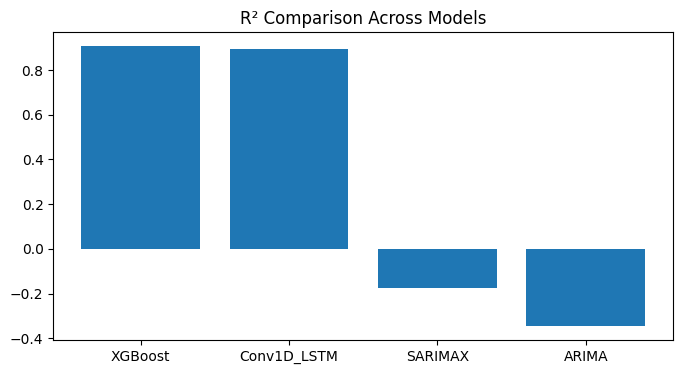

In [ ]:
# ============================================================
# GeoMagNet: Hybrid Time-Series Forecasting of NOAA Geomagnetic Activity (1994–2025)
# ============================================================

import os
import re
import math
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import Holt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dropout, Dense, InputLayer
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)

# ---------- CONFIG ----------
BASE_URL = "https://www.ngdc.noaa.gov/stp/space-weather/swpc-products/annual_reports/daily_solar_indices_summaries/daily_geomagnetic_data/"
YEARS = list(range(1994, 2026))
DOWNLOAD_FOLDER = "./geomagnetic_txts"
OUT_FOLDER = "./outputs"
os.makedirs(DOWNLOAD_FOLDER, exist_ok=True)
os.makedirs(OUT_FOLDER, exist_ok=True)

FORECAST_HORIZON = 30
SEASONALITY_THRESHOLD = 0.05
LAG = 30
EPOCHS_DL = 50
BATCH_SIZE_DL = 32
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# optional auto_arima
try:
    from pmdarima import auto_arima
    HAVE_AUTO_ARIMA = True
except Exception:
    HAVE_AUTO_ARIMA = False

# ---------- HELPERS ----------
def try_download_year_file(year):
    ypath = os.path.join(DOWNLOAD_FOLDER, f"{year}_DGD.txt")
    if os.path.exists(ypath):
        return [ypath]
    url = f"{BASE_URL}{year}_DGD.txt"
    try:
        r = requests.get(url, timeout=25)
        if r.status_code == 200:
            with open(ypath, "wb") as f:
                f.write(r.content)
            print(f"Downloaded {year}_DGD.txt")
            return [ypath]
    except Exception:
        pass

    qpaths = []
    for q in range(1, 5):
        qname = f"{year}Q{q}_DGD.txt"
        qpath = os.path.join(DOWNLOAD_FOLDER, qname)
        if os.path.exists(qpath):
            qpaths.append(qpath)
            continue
        qurl = f"{BASE_URL}{qname}"
        try:
            r = requests.get(qurl, timeout=25)
            if r.status_code == 200:
                with open(qpath, "wb") as f:
                    f.write(r.content)
                print(f"Downloaded {qname}")
                qpaths.append(qpath)
        except Exception:
            pass
    return qpaths if qpaths else None

def parse_noaa_txt(path):
    months = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
              'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
    records = []
    with open(path, "r", encoding="latin1", errors="ignore") as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            parts = re.split(r"\s+", line)
            try:
                if len(parts) >= 4 and parts[0].isdigit() and len(parts[0]) == 4 and parts[1].isdigit():
                    y, m, d = int(parts[0]), int(parts[1]), int(parts[2])
                    val = float(parts[3]) if parts[3] not in ("", "NaN", "nan") else np.nan
                    records.append((pd.Timestamp(y, m, d), val))
                    continue
            except Exception:
                pass
            try:
                if len(parts) >= 4 and parts[1][:3].title() in months:
                    d = int(parts[0])
                    m = months[parts[1][:3].title()]
                    y = int(parts[2])
                    if y < 50:
                        y += 2000
                    elif y < 100:
                        y += 1900
                    val = float(parts[3]) if parts[3] not in ("", "NaN", "nan") else np.nan
                    records.append((pd.Timestamp(y, m, d), val))
                    continue
            except Exception:
                pass
            iso = re.search(r"(\d{4})-(\d{2})-(\d{2})", line)
            if iso:
                try:
                    y, m, d = int(iso.group(1)), int(iso.group(2)), int(iso.group(3))
                    tokens_after = line[iso.end():].strip().split()
                    val = None
                    for t in tokens_after:
                        try:
                            val = float(t); break
                        except Exception:
                            continue
                    if val is None:
                        val = np.nan
                    records.append((pd.Timestamp(y, m, d), float(val)))
                except Exception:
                    pass
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records, columns=["Date", "Ap"]).drop_duplicates(subset=["Date"]).set_index("Date").sort_index()
    return df

def build_dataset():
    dfs = []
    for y in YEARS:
        files = try_download_year_file(y)
        if files:
            for f in files:
                d = parse_noaa_txt(f)
                if not d.empty:
                    dfs.append(d)
    if not dfs:
        raise ValueError("No data parsed.")
    df = pd.concat(dfs).sort_index()
    df = df[~df.index.duplicated(keep="first")]
    print(f"Combined {len(df):,} daily records ({df.index.min().year}–{df.index.max().year})")
    return df

# ---------- VISUALIZATIONS ----------
def plot_year_wise(series, out_folder=OUT_FOLDER, per_row=6):
    years = sorted(list({d.year for d in series.index}))
    n = len(years)
    cols = per_row
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 2.5*rows), sharey=True)
    axes = axes.flatten()
    for i, y in enumerate(years):
        ax = axes[i]
        s = series[series.index.year == y]
        ax.plot(s.index.dayofyear, s.values, linewidth=0.8)
        ax.set_title(str(y), fontsize=9)
        ax.grid(alpha=0.2)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.suptitle("Year-wise Daily Ap (day-of-year vs Ap)", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(os.path.join(out_folder, "yearwise_smallmultiples.png"), dpi=150)
    plt.show()

def plot_missing_summary(series, out_folder=OUT_FOLDER):
    df = series.to_frame("Ap")
    df["year"] = df.index.year
    missing_per_year = df.groupby("year")["Ap"].apply(lambda x: x.isna().sum())
    total_per_year = df.groupby("year")["Ap"].size()
    frac_missing = (missing_per_year / total_per_year).fillna(0)

    plt.figure(figsize=(12,4))
    plt.bar(missing_per_year.index.astype(str), missing_per_year.values)
    plt.xticks(rotation=45)
    plt.title("Missing Observations per Year (count)")
    plt.ylabel("Missing Count")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(out_folder, "missing_count_per_year.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(8,4))
    series.dropna().hist(bins=60)
    plt.title("Frequency curve of Ap values (non-missing)")
    plt.xlabel("Ap"); plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(out_folder, "ap_frequency_curve.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(12,4))
    plt.bar(frac_missing.index.astype(str), frac_missing.values)
    plt.xticks(rotation=45)
    plt.title("Fraction Missing per Year")
    plt.ylabel("Fraction Missing")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(out_folder, "missing_fraction_per_year.png"), dpi=150)
    plt.show()

# ---------- OUTLIER DETECTION ----------
def detect_outliers_iqr_visual(s, title="Outlier Detection (IQR)"):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    plt.figure(figsize=(14,5))
    plt.plot(s.index, s, color="steelblue", linewidth=0.7)
    plt.scatter(s.index[mask], s[mask], color="red", s=20)
    plt.title(title)
    plt.savefig(os.path.join(OUT_FOLDER, "outliers_detected.png"), dpi=150)
    plt.show()
    s_clean = s.copy()
    s_clean[mask] = s.median()
    plt.figure(figsize=(14,5))
    plt.plot(s_clean.index, s_clean, color="green", linewidth=0.7)
    plt.title("After Outlier Replacement")
    plt.savefig(os.path.join(OUT_FOLDER, "outliers_cleaned.png"), dpi=150)
    plt.show()
    print(f"{mask.sum()} outliers replaced")
    return s_clean

# ---------- TREND / SEASONALITY ----------
def check_trend_seasonality(series, period=365):
    stl = STL(series.dropna(), period=period, robust=True)
    res = stl.fit()
    total = np.var(series.dropna()) if len(series.dropna())>0 else 0.0
    ft = np.var(res.trend) / total if total else 0.0
    fs = np.var(res.seasonal) / total if total else 0.0
    return ft > SEASONALITY_THRESHOLD, fs > SEASONALITY_THRESHOLD, res

# ---------- SUPERVISED & METRICS ----------
def create_supervised(vals, lag=LAG):
    X, y = [], []
    for i in range(lag, len(vals)):
        X.append(vals[i-lag:i]); y.append(vals[i])
    return np.array(X), np.array(y)

def metrics(y_true, y_pred):
    return dict(
        MSE=mean_squared_error(y_true, y_pred),
        RMSE=math.sqrt(mean_squared_error(y_true, y_pred)),
        MAE=mean_absolute_error(y_true, y_pred),
        R2=r2_score(y_true, y_pred)
    )

# ---------- MAIN PIPELINE ----------
def run_pipeline(null_imputation_strategy="ffill"):
    print("="*70)
    print("GeoMagNet: Hybrid Time-Series Forecasting of NOAA Geomagnetic Activity")
    print("="*70)

    df = build_dataset()
    ts_orig = df["Ap"].astype(float).asfreq("D")

    plt.plot(ts_orig, color="navy")
    plt.title("Planetary A Index (1994–2025)")
    plt.savefig(os.path.join(OUT_FOLDER, "timeseries.png"), dpi=150)
    plt.show()

    plot_year_wise(ts_orig)
    plot_missing_summary(ts_orig)
    ts_cleaned = detect_outliers_iqr_visual(ts_orig)

    if null_imputation_strategy == "ffill":
        ts_filled = ts_cleaned.ffill().bfill()
    elif null_imputation_strategy == "bfill":
        ts_filled = ts_cleaned.bfill().ffill()
    elif null_imputation_strategy == "nearest":
        ts_filled = ts_cleaned.ffill().bfill()
    else:
        raise ValueError("invalid strategy")

    plt.figure(figsize=(14,4))
    plt.plot(ts_orig, alpha=0.4)
    plt.plot(ts_filled, alpha=0.9)
    plt.title(f"Missing-value imputation ({null_imputation_strategy})")
    plt.savefig(os.path.join(OUT_FOLDER, "imputed_timeseries.png"), dpi=150)
    plt.show()

    ts_smoothed = ts_filled.rolling(window=5, min_periods=1).mean()
    trend_flag, season_flag, stl_res = check_trend_seasonality(ts_smoothed)
    print(f"Trend detected: {trend_flag}, Seasonality detected: {season_flag}")
    stl_res.plot()
    plt.savefig(os.path.join(OUT_FOLDER, "decomposition.png"), dpi=150)
    plt.show()

    metrics_list = []
    train = ts_smoothed[:-FORECAST_HORIZON]
    test = ts_smoothed[-FORECAST_HORIZON:]

    # ---------- ARIMA + SARIMAX REPLACEMENT ----------
    print("Applying ARIMA and SARIMAX models...")
    try:
        if HAVE_AUTO_ARIMA:
            ar_model = auto_arima(train, seasonal=False, suppress_warnings=True, error_action="ignore")
            order = ar_model.order
            print("auto_arima selected order:", order)
            arima_fit = ARIMA(train, order=order).fit()
        else:
            arima_fit = ARIMA(train, order=(2,1,2)).fit()
        forecast_arima = arima_fit.forecast(FORECAST_HORIZON)
        metrics_list.append({"Model": "ARIMA", **metrics(test.values, forecast_arima.values)})
    except Exception as e:
        print("ARIMA failed:", e)

    try:
        sarimax_fit = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12),
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        forecast_sarimax = sarimax_fit.forecast(FORECAST_HORIZON)
        metrics_list.append({"Model": "SARIMAX", **metrics(test.values, forecast_sarimax.values)})
    except Exception as e:
        print("SARIMAX failed:", e)

    plt.figure(figsize=(10,4))
    plt.plot(train[-200:], label="Train", color="steelblue")
    plt.plot(test.index, test.values, label="Actual", color="black")
    plt.plot(test.index, forecast_arima, label="ARIMA Forecast", color="orange")
    plt.plot(test.index, forecast_sarimax, label="SARIMAX Forecast", color="purple")
    plt.legend(); plt.title("ARIMA & SARIMAX Forecast Comparison")
    plt.savefig(os.path.join(OUT_FOLDER, "arima_sarimax_forecast.png"), dpi=150)
    plt.show()

    # ---------- ADVANCED MODELS ----------
    vals = ts_smoothed.values.reshape(-1, 1)
    X_all, y_all = create_supervised(vals.flatten(), lag=LAG)
    split_idx = int(0.8 * len(X_all))
    X_tr, X_te = X_all[:split_idx], X_all[split_idx:]
    y_tr, y_te = y_all[:split_idx], y_all[split_idx:]
    scaler_x, scaler_y = MinMaxScaler(), MinMaxScaler()
    X_tr_scaled = scaler_x.fit_transform(X_tr.reshape(-1,1)).reshape(X_tr.shape)
    X_te_scaled = scaler_x.transform(X_te.reshape(-1,1)).reshape(X_te.shape)
    y_tr_scaled = scaler_y.fit_transform(y_tr.reshape(-1,1)).flatten()

    print("Training XGBoost")
    xg = xgb.XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=4, random_state=RANDOM_SEED, verbosity=0)
    xg.fit(X_tr_scaled, y_tr_scaled)
    pred_xg = scaler_y.inverse_transform(xg.predict(X_te_scaled).reshape(-1,1)).flatten()
    metrics_list.append({"Model": "XGBoost", **metrics(y_te.flatten(), pred_xg)})

    print("Training Conv1D-LSTM")
    Xc_tr = X_tr_scaled.reshape((X_tr_scaled.shape[0], X_tr_scaled.shape[1], 1))
    Xc_te = X_te_scaled.reshape((X_te_scaled.shape[0], X_te_scaled.shape[1], 1))
    model_dl = Sequential([
        InputLayer(input_shape=(LAG,1)),
        Conv1D(64,3,activation="relu"),
        LSTM(64,return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dense(1)
    ])
    model_dl.compile(optimizer="adam", loss="mse")
    es = EarlyStopping(patience=5, restore_best_weights=True)
    model_dl.fit(Xc_tr, y_tr_scaled, epochs=EPOCHS_DL, batch_size=BATCH_SIZE_DL, validation_split=0.1, verbose=0, callbacks=[es])
    pred_dl = scaler_y.inverse_transform(model_dl.predict(Xc_te, verbose=0)).flatten()
    metrics_list.append({"Model": "Conv1D_LSTM", **metrics(y_te.flatten(), pred_dl)})

    # ---------- RESULTS ----------
    df_metrics = pd.DataFrame(metrics_list).sort_values("R2", ascending=False)
    print("\nMODEL PERFORMANCE COMPARISON")
    print(df_metrics)
    df_metrics.to_csv(os.path.join(OUT_FOLDER, "model_performance.csv"), index=False)

    plt.figure(figsize=(8,4))
    plt.bar(df_metrics["Model"], df_metrics["R2"])
    plt.title("R² Comparison Across Models")
    plt.savefig(os.path.join(OUT_FOLDER, "model_r2_comparison.png"), dpi=150)
    plt.show()

    return df_metrics

# ---------- RUN ----------
if __name__ == "__main__":
    metrics_df = run_pipeline()
